In [42]:
import numpy as np
def show(A,b=None,fmt='%+7.2f'):
    """
    Function to more neatly print out the matrix.
    """
    print('--')
    for i, As in enumerate(A):
        cr=''
        for j, a in enumerate(As):
            cr=f'{cr} {fmt}'%a
        if type(b)!=type(None):
            cr=f'{cr} | {fmt}'%b[i]
        print(cr)

def show1(a,fmt='%+7.2f'):
    print('--')
    cr=''
    for i, v in enumerate(a):
        cr=f'{cr} {fmt}'%v
    print(cr)




# initial empty A.
A=np.zeros((3,4))
# filling up the matrix.
A[0,:]=2,3,1,9
A[1,:]=1,-1,1,1
A[2,:]=3,11,5,35
show(A)#,fmt='%7.2f')

--
   +2.00   +3.00   +1.00   +9.00
   +1.00   -1.00   +1.00   +1.00
   +3.00  +11.00   +5.00  +35.00


# Jacobi method
$$
x_i^{(k+1)}=\frac{1}{A_{ii}}\bigg(b_i-\sum_{j\ne i}^nA_{ij}x_j^{(k)}\bigg)
$$


--
  +11.00  -11.00   +5.00 |   +3.00
  +12.00  +32.00   +1.00 |   +4.00
  +13.00  -10.00  -20.00 |   +5.00
--
   +0.3109   +0.0083   -0.0504


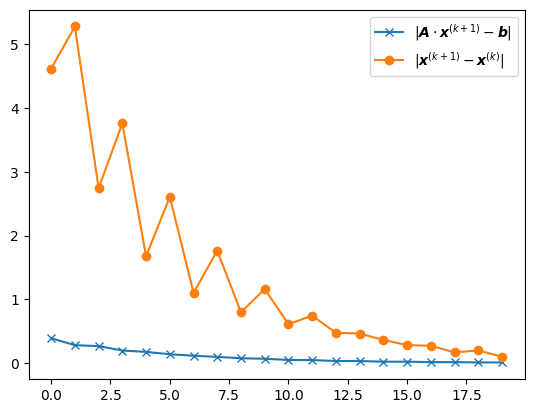

In [91]:
A=np.zeros((3,3))
b=np.zeros(3)
# filling up the matrix.
A[1,:]=12,32,1
A[0,:]=11,-11,5
A[2,:]=13,-10,-20

b[:]=3,4,5
show(A,b)

ndim=b.shape[0]
x=np.zeros(ndim)
tol=1e-4
err=tol*2
k=0
hist=[]
while err> tol and k<20:
    newx=np.zeros(ndim)
    for icol in range(ndim):
        summation=0.
        for jrow in range(ndim):
            if icol==jrow:
                pass
            else:
                summation+=A[icol,jrow]*x[jrow]
        newx[icol]=(b[icol]-summation)/A[icol,icol]
        #x[icol]=1/A[icol,icol]*(b[icol]-)
    err=np.sqrt(((newx-x)**2).sum())
    Ea=np.sqrt(((A@newx-b)**2).sum())
    x[::]=newx[::]
    hist.append([err,Ea])
    k+=1
hist=np.array(hist)
show1(x,fmt='%+9.4f')
import matplotlib.pyplot as plt
plt.plot(hist[:,0],'-x',label=r'$|\boldsymbol{A}\cdot\boldsymbol{x}^{(k+1)}-\boldsymbol{b}|$')
plt.plot(hist[:,1],'-o',label=r'$|\boldsymbol{x}^{(k+1)}-\boldsymbol{x}^{(k)}|$')
plt.legend()

--
  +12.00   +3.00   +1.00 |   +3.00
   +9.00  -11.00   +5.00 |   +4.00
   +1.00  -10.00  -20.00 |   +5.00
--
   +0.3068   -0.1787   -0.1453


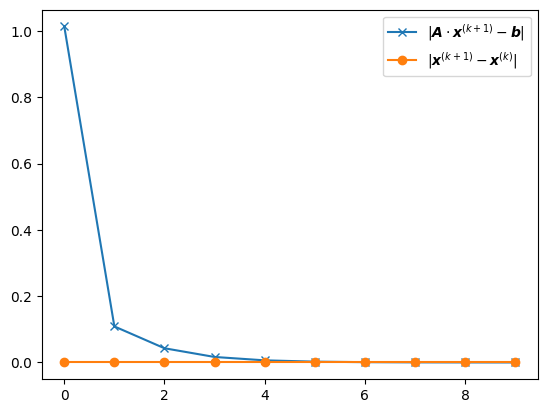

In [ ]:
A=np.zeros((3,3))
b=np.zeros(3)
# filling up the matrix.
A[0,:]=12,3,1
A[1,:]=9,-11,5
A[2,:]=1,-10,-20

b[:]=3,4,5
show(A,b)

ndim=b.shape[0]
x=np.zeros(ndim)
tol=1e-4
err=tol*2
k=0
hist=[]
while err> tol and k<100:
    newx=np.zeros(ndim)
    for icol in range(ndim):
        summation=0.
        for jrow in range(ndim):
            if icol==jrow:
                pass
            else:
                summation+=A[icol,jrow]*x[jrow]
        newx[icol]=(b[icol]-summation)/A[icol,icol] #!! Jacobi
        x[icol]=newx[icol]
        #x[icol]=(b[icol]-summation)/A[icol,icol] ## Gauss-Seidel
        #x[icol]=1/A[icol,icol]*(b[icol]-)
    #err=np.sqrt(((newx-x)**2).sum())
    #Ea=np.sqrt(((A@newx-b)**2).sum())
    err=np.sqrt(((A@x-b)**2).sum())

    x[::]=newx[::]
    hist.append([err,Ea])
    k+=1
hist=np.array(hist)
show1(x,fmt='%+9.4f')
import matplotlib.pyplot as plt
plt.plot(hist[:,0],'-x',label=r'$|\boldsymbol{A}\cdot\boldsymbol{x}^{(k+1)}-\boldsymbol{b}|$')
plt.plot(hist[:,1],'-o',label=r'$|\boldsymbol{x}^{(k+1)}-\boldsymbol{x}^{(k)}|$')
plt.legend()